# Analisis de Datos de Empresa de Cambio de Divisas

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


## 1. Carga de Datos

In [80]:
df = pd.read_excel("../data/deals.xlsx",parse_dates=["Fecha de creación", "Fecha de emisión del Documento"])
df["Fecha de emisión del Documento"] = pd.to_datetime(df["Fecha de emisión del Documento"],dayfirst=True)
df["Fecha de creación"] = pd.to_datetime(df["Fecha de creación"],dayfirst=True)
df["año_mes"] = pd.to_datetime(df["Fecha de emisión del Documento"],dayfirst=True).dt.to_period("M").astype(str)

## 2. Análisis Exploratorio de los Datos

In [21]:
df.head()

,Fecha de creación,Tipo de documento,Fecha de emisión del Documento,N° Doc,Nº Nota,Ficha de cliente,Caja,Divisa,Transacción,Operación,Estado,Monto,Tasa de cambio,Total,Detalle,Unnamed: 15
0,02-01-2021,Boleta,02-01-2021,1.0,NaN,NaN,CAJA 02,Dolar USA,Compra,Normal,Vigente,100.0,705.0,70500,NaN,0.0
1,02-01-2021,Boleta,02-01-2021,2.0,NaN,NaN,CAJA 01,Dolar USA,Compra,Especial,Vigente,153.0,720.0,110160,NaN,0.0
2,02-01-2021,Boleta,02-01-2021,3.0,NaN,NaN,CAJA 01,Dolar USA,Compra,Especial,Vigente,265.0,720.0,190800,NaN,0.0
3,02-01-2021,Boleta,02-01-2021,4.0,NaN,NaN,CAJA 01,Dolar USA,Venta,Especial,Vigente,402.0,752.0,302304,NaN,12864.0
4,02-01-2021,Boleta,02-01-2021,5.0,NaN,NaN,CAJA 02,Dolar USA,Compra,Especial,Vigente,100.0,710.0,71000,NaN,0.0


## 2. Analisis Exaploratorio de los datos

In [54]:
df.shape

(61287, 17)

In [56]:
df.dtypes

Fecha de creación                  object
Tipo de documento                  object
Fecha de emisión del Documento     object
N° Doc                            float64
Nº Nota                           float64
Ficha de cliente                   object
Caja                               object
Divisa                             object
Transacción                        object
Operación                          object
Estado                             object
Monto                             float64
Tasa de cambio                    float64
Total                               int64
Detalle                            object
Unnamed: 15                       float64
año_mes                            object
dtype: object

In [57]:
df.isnull().sum()

Fecha de creación                     0
Tipo de documento                     0
Fecha de emisión del Documento       21
N° Doc                               21
Nº Nota                           60794
Ficha de cliente                  61089
Caja                                  0
Divisa                                0
Transacción                           0
Operación                             0
Estado                                0
Monto                                 0
Tasa de cambio                        0
Total                                 0
Detalle                           61284
Unnamed: 15                           0
año_mes                               0
dtype: int64

In [59]:
df.duplicated().sum()

0

In [61]:
df.describe()

,N° Doc,Nº Nota,Monto,Tasa de cambio,Total,Unnamed: 15
count,61266.000000,493.000000,6.128700e+04,6.128700e+04,6.128700e+04,61287.000000
mean,32358.339193,263.054767,3.186951e+03,9.265124e+02,3.839013e+05,5191.182177
std,19430.061719,153.329004,5.962630e+04,1.176029e+04,5.787578e+05,12458.273965
min,1.000000,9.000000,1.000000e-01,7.000000e-02,1.000000e+00,-35225.028543
25%,15314.250000,132.000000,1.000000e+02,8.000000e+02,8.040000e+04,0.000000
50%,30631.500000,256.000000,2.200000e+02,8.500000e+02,1.690000e+05,0.000000
75%,50007.750000,381.000000,6.200000e+02,9.200000e+02,4.150000e+05,4883.167105
max,65324.000000,554.000000,1.000000e+07,1.190000e+06,1.699968e+07,445000.000000


In [72]:
print(f"Numero de divisas transadas: {df.Divisa.nunique()} \n")
print(f"Divisas transadas:\n {df.Divisa.unique()}")


Numero de divisas transadas: 20 

Divisas transadas:
 ['Dolar USA' 'Dolar Canada' 'Real' 'Euro' 'Sol Peruano' 'Peso Argentino'
 'Corona Sueca' 'Peso Mexicano' 'Dolar Australiano' 'Peso Colombiano'
 'Corona Noruega' 'Franco Suizo' 'Libra Esterlina' 'Peso Boliviano'
 'Yuan Chino' 'Guarani Paraguayo' 'Peso Uruguayo' 'Dolar Neozelandes'
 'Yen Japones' 'Moneda de Oro 100']


In [97]:
def plot_total_usd_by_transaction(df: pd.DataFrame):
    df_usd = df[df["Divisa"] == "Dolar Canada"].copy()
    df_usd["Fecha"] = df_usd["Fecha de emisión del Documento"].dt.date  # para agrupar por día

    grouped = df_usd.groupby(["Fecha", "Transacción"])["Total"].sum().reset_index()
    pivot = grouped.pivot(index="Fecha", columns="Transacción", values="Total").fillna(0)

    fig, ax = plt.subplots(figsize=(12, 5))
    pivot[["Compra"]].plot(ax=ax)
    ax.set_title("Monto Total Diario en USD por Transacción")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Total en USD")
    ax.legend(title="Transacción")
    plt.xticks(rotation=45)
    #plt.tight_layout()
    #plt.show()
    


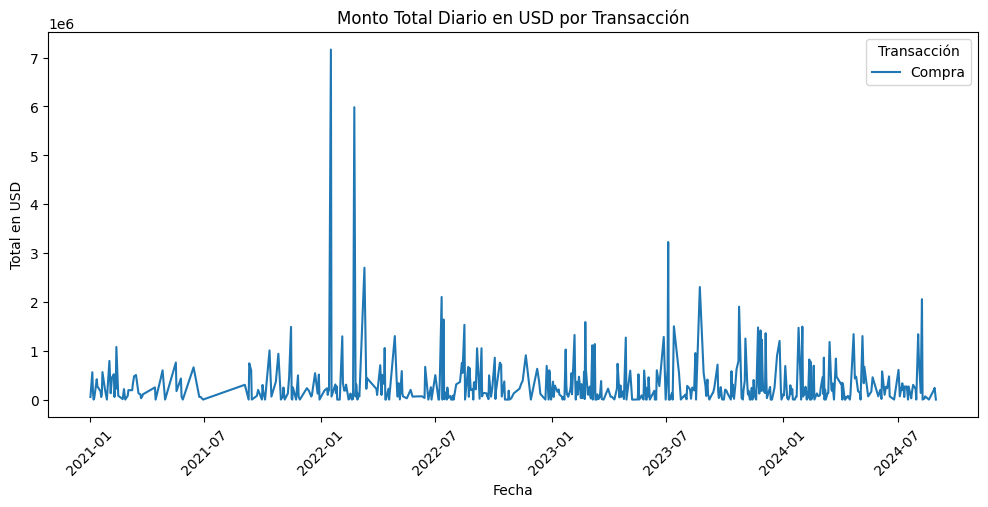

In [98]:
plot_total_usd_by_transaction(df)

In [83]:
df[df["Divisa"]=="USD"]

,Fecha de creación,Tipo de documento,Fecha de emisión del Documento,N° Doc,Nº Nota,Ficha de cliente,Caja,Divisa,Transacción,Operación,Estado,Monto,Tasa de cambio,Total,Detalle,Unnamed: 15,año_mes


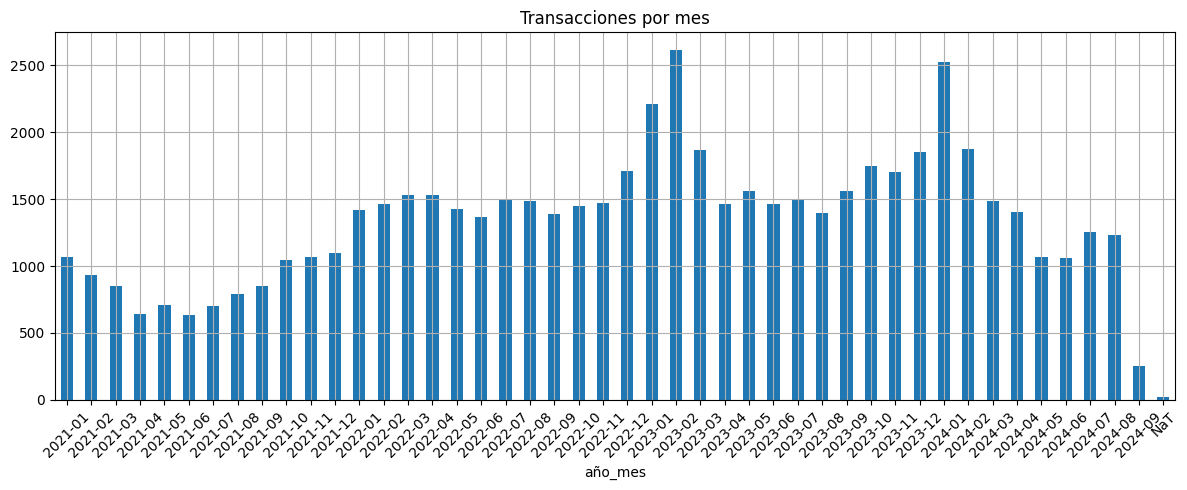

In [ ]:
plt.figure(figsize=(12, 5))
df["año_mes"].value_counts().sort_index().plot(kind="bar", title="Transacciones por mes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

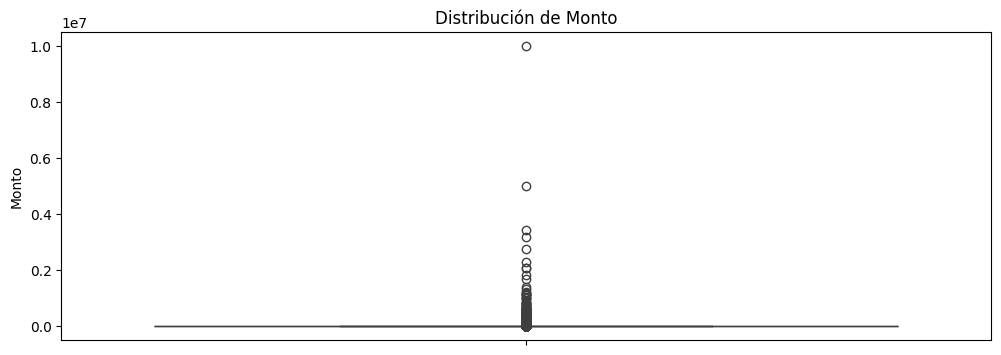

In [44]:
plt.figure(figsize=(12, 4))
sns.boxplot(df["Monto"])
plt.title("Distribución de Monto")
plt.show()

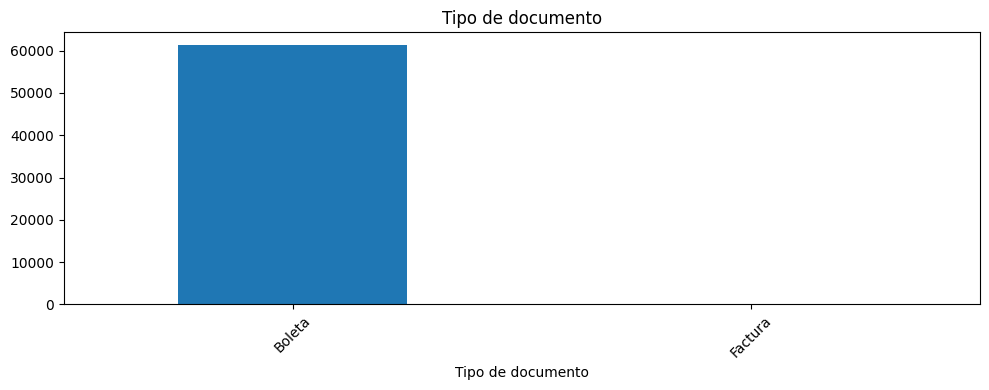

In [45]:
plt.figure(figsize=(10, 4))
df["Tipo de documento"].value_counts().plot(kind="bar", title="Tipo de documento")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

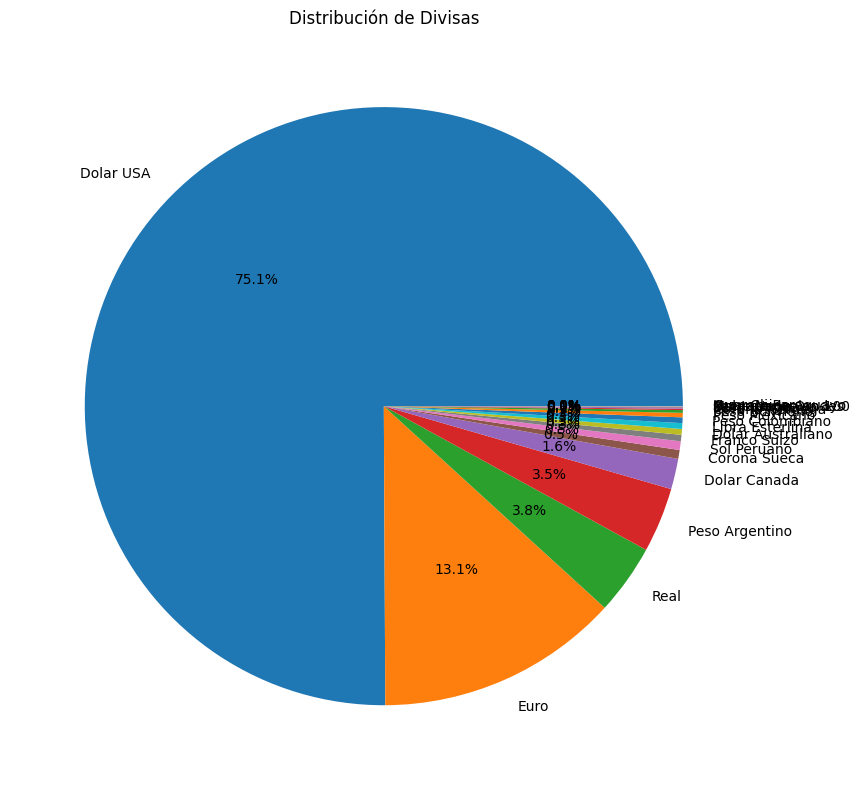

In [48]:
plt.figure(figsize=(15, 8))
df["Divisa"].value_counts().plot(kind="pie", autopct='%1.1f%%', title="Distribución de Divisas")
plt.ylabel("")
plt.tight_layout()
plt.show()

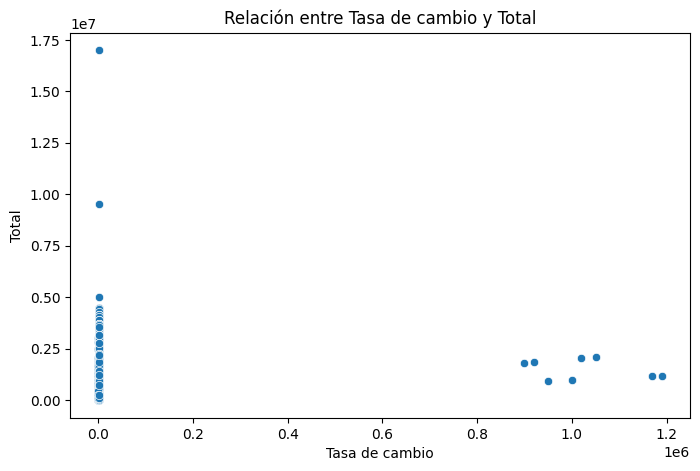

In [50]:
# --- Outliers ---
for col in ["Monto", "Total"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"\n⚠️ Outliers en {col}: {len(outliers)} registros")


⚠️ Outliers en Monto: 7596 registros

⚠️ Outliers en Total: 6827 registros


In [53]:
df[df["Total"]>=10000000]

,Fecha de creación,Tipo de documento,Fecha de emisión del Documento,N° Doc,Nº Nota,Ficha de cliente,Caja,Divisa,Transacción,Operación,Estado,Monto,Tasa de cambio,Total,Detalle,Unnamed: 15,año_mes
59390,22-07-2024,Factura,22-07-2024,64.0,NaN,JORGE ALEJANDRO MONTERO FUENTES,CAJA 01,Dolar USA,Venta,Normal,Vigente,17708.0,960.0,16999680,NaN,319019.414644,2024-07
